# Task for session2_cont and session3: 
## Edge-Preserving Denoising Filters & Feature Matching

**Instructions:**  
**please dont use .py to solve this task, just use tasks2.ipynb and edit the cells.**
- After forking the [SkyXperts-Vision-Course repo](https://github.com/ffathy-tdx/SkyXperts-Vision-Course) on GitHub. (you should have already dont this in the last session & uploaded task1)
- Go to your fork of the repo on GitHub.
- At the top, look for a yellow box that says “This branch is X commits behind…”
- Click the Sync fork or Update branch button.
The new task will show up in your tasks/ folder.  
- Upload your task to your forked repo (like you've done with task1 before)
---

## 1. DoG, LoG, and Edge-Preserving Denoising Filters

**Task:**
- Briefly read the descriptions below, then apply each filter to `'sample.jpg'` (or any test image you choose).
- Compare the results visually and write your observations.

**Background:**
- **DoG (Difference of Gaussian):** Used for edge detection by subtracting two blurred versions of the image (with different Gaussian sigmas).
- **LoG (Laplacian of Gaussian):** Uses a single Gaussian blur followed by Laplacian to highlight regions of rapid intensity change (edges).
- **Edge-Preserving Denoising (Bilateral Filter):** Smooths image while preserving edges (unlike simple Gaussian blur). You've already used this at the end of task1.

---

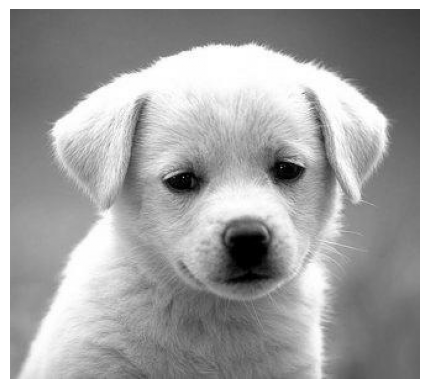

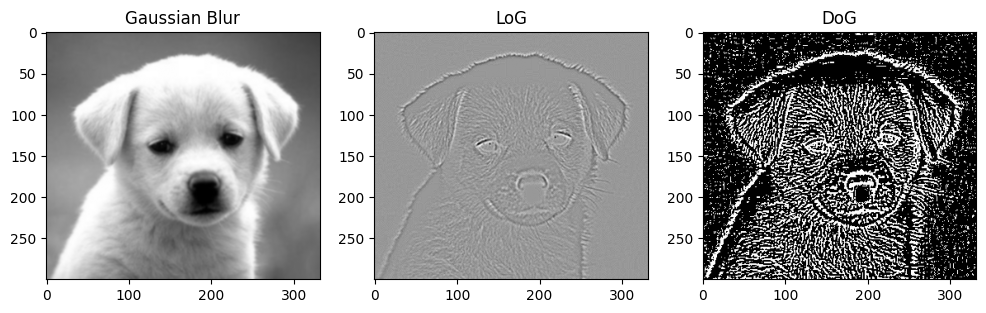

In [9]:
import cv2
import matplotlib.pyplot as plt

# Correct full path
img = cv2.imread(r"c:/Users/maryam/Desktop/task22/SkyXperts-Vision-Course/Session1/images/dog.jpg", 0)



plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()
blur1 = cv2.GaussianBlur(img, (5,5), 1)
blur2 = cv2.GaussianBlur(img, (5,5), 2)
dog = blur1 - blur2
# TODO: Apply LoG
blur = cv2.GaussianBlur(img, (5,5), 1)
log = cv2.Laplacian(blur, cv2.CV_64F)
# TODO: Apply bilateral (edge-preserving) filter
bilateral = cv2.bilateralFilter(img, 9, 75, 75)
# Show all results for comparison
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(blur, cmap="gray"); plt.title("Gaussian Blur")
plt.subplot(1,3,2); plt.imshow(log, cmap="gray"); plt.title("LoG")
plt.subplot(1,3,3); plt.imshow(dog, cmap="gray"); plt.title("DoG")
plt.show()



**Q1: What differences do you observe between DoG, LoG, and the edge-preserving filter?**

_Write your observations here"dog strong edges are visible"
"log produces sharper and more continuous edging "
"bilateral is for smoothing"
._ 

## 2. Keypoints & Descriptors: SIFT vs. ORB

**Task:**
- Detect and plot keypoints on `'sample.jpg'` using SIFT and ORB.
- Compare the number and distribution of detected keypoints.

**Background:**
- **Keypoints:** Distinctive image points (corners/blobs) useful for matching.
- **Descriptors:** Vectors that describe local patches around keypoints for comparison/matching.

---

Number of SIFT keypoints: 189
Number of ORB keypoints: 469


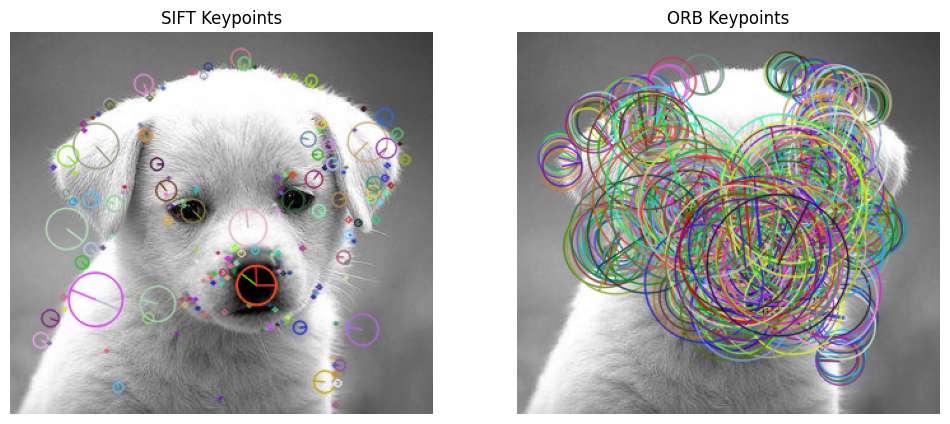

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load grayscale for detection
gray = cv2.imread(r"c:/Users/maryam/Desktop/task22/SkyXperts-Vision-Course/Session1/images/dog.jpg", 0)
# Load color for visualization
img_color = cv2.imread(r"c:/Users/maryam/Desktop/task22/SkyXperts-Vision-Course/Session1/images/dog.jpg")
#()
# Detect and plot SIFT keypoints
sift = cv2.SIFT_create()
sift_keypoints, sift_des = sift.detectAndCompute(gray, None)
# Detect and plot ORB keypoints
orb = cv2.ORB_create()
orb_keypoints, orb_des = orb.detectAndCompute(gray, None)

# TODO: Count and compare number of keypoints for SIFT and ORB
print("Number of SIFT keypoints:", len(sift_keypoints))
print("Number of ORB keypoints:", len(orb_keypoints))

img_sift = cv2.drawKeypoints(img_color, sift_keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img_orb = cv2.drawKeypoints(img_color, orb_keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)


plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))
plt.title("SIFT Keypoints")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_orb, cv2.COLOR_BGR2RGB))
plt.title("ORB Keypoints")
plt.axis("off")

plt.show()

#plt. is working for vs not cv.

**Q2: How do the number and distribution of keypoints differ between SIFT and ORB?**

_Write your answer here.

 sift :Usually detects fewer but more distinctive keypoints
 orb:Designed to be fast, so it finds more keypoints by default._

## 3. Feature Matching with Descriptors

**Task:**
- Load a second image (e.g., `'sample2.jpg'`).
- Detect keypoints/descriptors using SIFT or ORB in both images.
- Match the features between the images using BFMatcher or FLANN.
- Plot the top matches.

**Background:**
- **Feature matching** helps recognize objects/scenes or estimate image transformations.

---

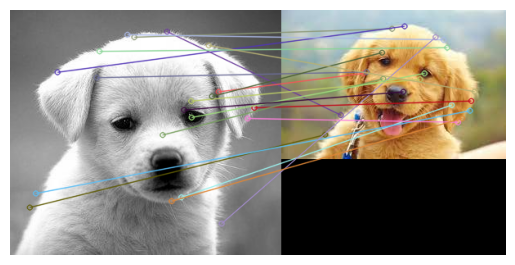

In [2]:
# Load second image
import cv2
import numpy as np
img1 = cv2.imread(r"c:/Users/maryam/Desktop/task22/SkyXperts-Vision-Course/Session1/images/dog.jpg")
img2 = cv2.imread(r"c:/Users/maryam/Desktop/task22/SkyXperts-Vision-Course/Session1/images/dogBGR.jpg")

img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)


# Detect SIFT keypoints/descriptors in both images
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(img1_gray, None)
kp2, des2 = sift.detectAndCompute(img2_gray, None)

matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

# Convert the images to grayscale 
img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)



# BFMatcher with default params

matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = matcher.match(des1, des2)

# Draw matches
matches = sorted(matches, key = lambda x:x.distance)
numberofmatches = 20
matched_img = cv2.drawMatches(
    img1, kp1, img2, kp2, matches[:numberofmatches], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


# bonus TODO: Try with ORB or FLANN if you like

**Q3: What do you notice about the feature matches? Are there any mismatches or errors? How might you improve the matching process?**

_Write your answer here._

**Bonus Task (Optional, for extra credit):**
- Try using different image preprocessing steps *before* edge detection or feature extraction.
    - For example:
        - Add noise to your image (e.g., Gaussian noise, salt-and-pepper noise).
        - Apply a sharpening filter to your image.
    - Then, run DoG, LoG, or any edge-preserving filter and observe the changes.
- **What to do:**
    - Show the results (images/plots) for at least one type of preprocessing + edge detection.
    - Briefly explain:
        - How does noise affect edge maps or keypoints?
        - Does sharpening make features easier or harder to detect/match?

**You can add your code and observations in the cells below.**


In [ ]:
# Write your code here

_What are your observations?_
write them here

## 4. Reflection (Optional)

- What was the most challenging or interesting part of this task for you?
- Any feedback or thoughts?

_Write your reflection here._